In [1]:
import networkx as nx
import requests
import fastobo
import matplotlib.pyplot as plt

In [ ]:
# obo_url = "https://purl.obolibrary.org/obo/go.owl"
# response = requests.get(obo_url)

In [6]:
import rdflib
import networkx as nx
import matplotlib.pyplot as plt

# Load RDF data from the OWL file
g = rdflib.Graph()
g.parse("go.owl", format="xml")

# Create a NetworkX directed graph
G = nx.DiGraph()

In [5]:
# Add nodes and edges to the graph based on RDF triples
# incorporate all node attributes in the graph
for s, p, o in g[:3]:
    print(s, p, o)
    G.add_node(s, label=s)
    G.add_node(o, label=o)
    G.add_edge(s, o, label=p)

In [63]:
# get number of nodes and edges
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

G.nodes["GO_0001686"]

Number of nodes: 585732
Number of edges: 1424397


{}

{'GO:0000128': None}


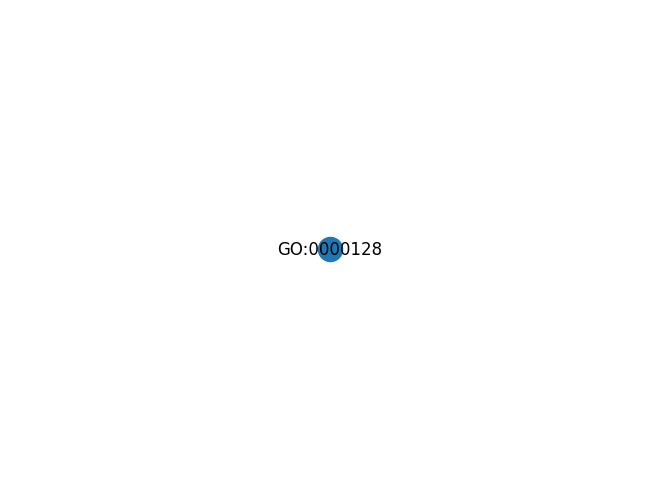

In [54]:
source_node = "GO:0000128"
distance = 5

# Find all nodes within the specified distance
nodes_within_distance = [
    node
    for node, length in nx.single_source_shortest_path_length(G, source_node).items()
    if length <= distance
]

# Create a subgraph of G with only the nodes within the specified distance
H = G.subgraph(nodes_within_distance)

# Draw the subgraph with "name" from node properties as labels
pos = nx.spring_layout(H)
node_name_labels = {node: H.nodes[node].get("name") for node in H.nodes}
nx.draw(H, pos, with_labels=True)
print(node_name_labels)

KeyboardInterrupt: 

In [4]:

# with open("go.owl", "wb") as file:
#     file.write(response.content)

In [7]:
go = fastobo.load("go.obo")

In [49]:
G = nx.DiGraph()

for frame in go:
    # add nodes and addged and add node attributes
    if isinstance(frame, fastobo.term.TermFrame):
        print(frame.__dir__())
        G.add_node(str(frame.id), **{"name":frame.name, "namespace":frame.namespace})
        for clause in frame:
            if isinstance(clause, fastobo.term.IsAClause):
                G.add_edge(str(frame.id), str(clause.term))

['__new__', '__repr__', '__str__', '__len__', '__getitem__', '__setitem__', '__delitem__', '__add__', 'append', 'clear', 'copy', 'count', 'insert', 'pop', 'reverse', 'id', '__doc__', '__module__', '__hash__', '__getattribute__', '__setattr__', '__delattr__', '__lt__', '__le__', '__eq__', '__ne__', '__gt__', '__ge__', '__init__', '__reduce_ex__', '__reduce__', '__getstate__', '__subclasshook__', '__init_subclass__', '__format__', '__sizeof__', '__dir__', '__class__']


AttributeError: 'fastobo.term.TermFrame' object has no attribute 'name'

In [56]:
# print all nodes connected in 3 nodes or less distance to GO:0140657
print(nx.single_source_shortest_path_length(G, "GO:0140657", cutoff=3))

{'GO:0140657': 0}


{'GO:0009987': None, 'GO:0098609': None, 'GO:0098610': None, 'GO:0051703': None, 'GO:0000128': None, 'GO:0008150': None, 'GO:0007155': None}


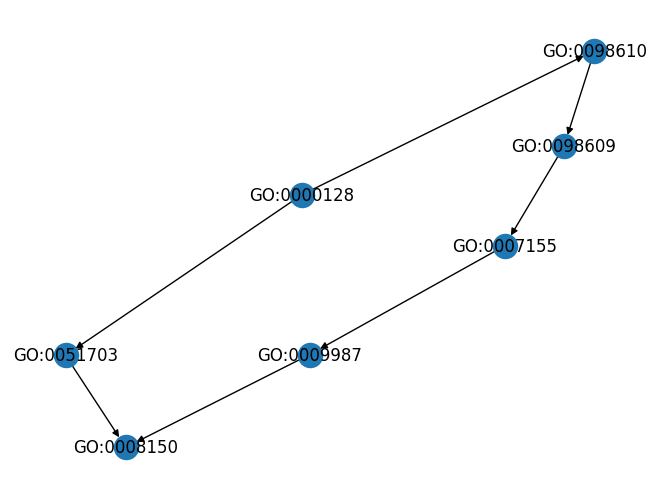

In [36]:
source_node = "GO:0000128"
distance = 5

# Find all nodes within the specified distance
nodes_within_distance = [
    node
    for node, length in nx.single_source_shortest_path_length(G, source_node).items()
    if length <= distance
]

# Create a subgraph of G with only the nodes within the specified distance
H = G.subgraph(nodes_within_distance)

# Draw the subgraph with "name" from node properties as labels
pos = nx.spring_layout(H)
node_name_labels = {node: H.nodes[node].get("name") for node in H.nodes}
nx.draw(H, pos, with_labels=True)
print(node_name_labels)

In [30]:
superclass_nodes = networkx.descendants(G, "GO:0140657")
superclass_nodes.add("GO:0140657")
super_graph = G.subgraph(superclass_nodes)

In [31]:
# vis all descendants of GO:0140657

vis = networkx.nx_agraph.to_agraph(super_graph)

ImportError: requires pygraphviz http://pygraphviz.github.io/

In [39]:
G.nodes["GO:0098610"]

{}

In [33]:
# print all attributes of GO:0009975
for frame in go:
    if isinstance(frame, fastobo.term.TermFrame):
        if str(frame.id) == "GO:0008150":
            for clause in frame:
                print(clause)

name: biological_process
namespace: biological_process
alt_id: GO:0000004
alt_id: GO:0007582
alt_id: GO:0044699
def: "A biological process is the execution of a genetically-encoded biological module or program. It consists of all the steps required to achieve the specific biological objective of the module. A biological process is accomplished by a particular set of molecular functions carried out by specific gene products (or macromolecular complexes), often in a highly regulated manner and in a particular temporal sequence." [GOC:pdt]
comment: Note that, in addition to forming the root of the biological process ontology, this term is recommended for the annotation of gene products whose biological process is unknown. When this term is used for annotation, it indicates that no information was available about the biological process of the gene product annotated as of the date the annotation was made; the evidence code 'no data' (ND), is used to indicate this.
subset: goslim_candida
sub